In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

RAW = Path("../data/data_raw")
PROC = Path("../data/data_processed")
PROC.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)


In [3]:
# List what we downloaded
list(RAW.glob("*"))

[WindowsPath('../data/data_raw/atm_transactions.csv'),
 WindowsPath('../data/data_raw/btcusd_1-min_data.csv')]

In [4]:
atm_raw = pd.read_csv("../data/data_raw/atm_transactions.csv")
btc_raw = pd.read_csv("../data/data_raw/btcusd_1-min_data.csv")

In [5]:
atm_raw.head()

,atmId,atmName,atmCity,atmAddress,totalBalance,numberIncomeTransaction,numberOutcomeTransaction,totalIncome,totalOutcome,totalNumberTransaction,day,transactionTime
0,atm350000,ALİAĞA BAĞLI ŞB,Izmir,Aliağa Petkim Tesisleri,40000,0,0,0,0,0,Wednesday,2020-01-01 00:00:00
1,atm350001,ALİAĞA İSTİKLAL CADDESİ,Izmir,ATATÜRK İSTİKLAL CD. NO:97,40000,0,0,0,0,0,Wednesday,2020-01-01 00:00:00
2,atm350002,ALİAĞA PAZARYERİ,Izmir,ALİAĞA KAPALI PAZAR GİRİŞİ,40000,0,0,0,0,0,Wednesday,2020-01-01 00:00:00
3,atm350003,ALİAĞA SAHİL PARKI,Izmir,ALİAĞA HİKMET CD.SAHİL PARKI ÖNÜ,40000,0,0,0,0,0,Wednesday,2020-01-01 00:00:00
4,atm350004,ALİAĞA ŞUBE-1,Izmir,İstiklal Caddesi No: 64 / A,40000,0,0,0,0,0,Wednesday,2020-01-01 00:00:00


In [6]:
btc_raw.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [7]:
print("ATM columns:", list(atm_raw.columns))
print("BTC columns:", list(btc_raw.columns))

ATM columns: ['atmId', 'atmName', 'atmCity', 'atmAddress', 'totalBalance', 'numberIncomeTransaction', 'numberOutcomeTransaction', 'totalIncome', 'totalOutcome', 'totalNumberTransaction', 'day', 'transactionTime']
BTC columns: ['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume']


In [8]:
# Normalize ATM data
atm = atm_raw.copy()

# Parse date
atm["date"] = pd.to_datetime(atm["transactionTime"])

# Core columns
atm_norm = pd.DataFrame({
    "date": atm["date"].dt.date,  # drop time → daily
    "atm_id": atm["atmId"].astype(str),
    "atm_city": atm["atmCity"],
    "atm_address": atm["atmAddress"],
    "total_balance": atm["totalBalance"],
    "income_txn_count": atm["numberIncomeTransaction"],
    "outcome_txn_count": atm["numberOutcomeTransaction"],
    "total_income": atm["totalIncome"],
    "total_outcome": atm["totalOutcome"],
    "total_txn_count": atm["totalNumberTransaction"]
})

# Aggregate to daily per ATM (summing)
atm_daily = (atm_norm
             .groupby(["date","atm_id","atm_city"], as_index=False)
             .agg(total_balance=("total_balance","last"),
                  income_txn_count=("income_txn_count","sum"),
                  outcome_txn_count=("outcome_txn_count","sum"),
                  total_income=("total_income","sum"),
                  total_outcome=("total_outcome","sum"),
                  total_txn_count=("total_txn_count","sum"))
            )

# For forecasting, define withdrawals as total_outcome
atm_daily["withdrawals_usd"] = atm_daily["total_outcome"]

atm_daily.head()

,date,atm_id,atm_city,total_balance,income_txn_count,outcome_txn_count,total_income,total_outcome,total_txn_count,withdrawals_usd
0,2020-01-01,atm350000,Izmir,26835,525,593,33270,39650,1118,39650
1,2020-01-01,atm350001,Izmir,27090,587,639,38950,42550,1226,42550
2,2020-01-01,atm3500010,Izmir,32330,881,970,52165,58700,1851,58700
3,2020-01-01,atm35000100,Izmir,27945,509,663,33450,41795,1172,41795
4,2020-01-01,atm35000101,Izmir,34045,529,607,34340,41815,1136,41815


In [9]:
# Normalize BTC data
btc = btc_raw.copy()

# 1) Convert Unix epoch to datetime, then to *date* (not datetime)
btc["date"] = pd.to_datetime(btc["Timestamp"], unit="s", errors="coerce").dt.date

# 2) Drop rows without a valid date or price columns
btc = btc.dropna(subset=["date", "Close"])

# 3) Group by the explicit 'date' column (so it remains a real column, not an index)
btc_daily = (btc.groupby("date", as_index=False)
               .agg(btc_open=("Open", "first"),
                    btc_high=("High", "max"),
                    btc_low=("Low", "min"),
                    btc_close=("Close", "last"),
                    btc_volume=("Volume", "sum"))
            )

# 4) Sort by date and create rolling signals
btc_daily = btc_daily.sort_values("date").reset_index(drop=True)
btc_daily["btc_pct_change_1d"] = btc_daily["btc_close"].pct_change().fillna(0.0)
btc_daily["btc_7d_roc"]        = btc_daily["btc_close"].pct_change(7).fillna(0.0)
btc_daily["btc_7d_ma"]         = btc_daily["btc_close"].rolling(7).mean()
btc_daily["btc_volatility_7d"] = btc_daily["btc_close"].pct_change().rolling(7).std()


In [10]:
# 5) Quick sanity checks
print("btc_daily columns:", list(btc_daily.columns))
print("btc_daily date range:", min(btc_daily["date"]), "→", max(btc_daily["date"]))

btc_daily columns: ['date', 'btc_open', 'btc_high', 'btc_low', 'btc_close', 'btc_volume', 'btc_pct_change_1d', 'btc_7d_roc', 'btc_7d_ma', 'btc_volatility_7d']
btc_daily date range: 2012-01-01 → 2025-09-29


In [11]:
print(btc_daily.head())

         date  btc_open  btc_high  btc_low  btc_close  btc_volume  \
0  2012-01-01      4.58      4.84     4.58       4.84   10.000000   
1  2012-01-02      4.84      5.00     4.84       5.00   10.100000   
2  2012-01-03      5.00      5.32     5.00       5.29  107.085281   
3  2012-01-04      5.29      5.57     4.93       5.57  107.233260   
4  2012-01-05      5.57      6.46     5.57       6.42   70.328742   

   btc_pct_change_1d  btc_7d_roc  btc_7d_ma  btc_volatility_7d  
0           0.000000         0.0        NaN                NaN  
1           0.033058         0.0        NaN                NaN  
2           0.058000         0.0        NaN                NaN  
3           0.052930         0.0        NaN                NaN  
4           0.152603         0.0        NaN                NaN  


In [12]:
dmin, dmax = atm_daily["date"].min(), atm_daily["date"].max()
calendar = pd.DataFrame({"date": pd.date_range(dmin, dmax, freq="D").date})
calendar["day_of_week"] = pd.to_datetime(calendar["date"]).dt.day_name()
calendar["is_weekend"] = pd.to_datetime(calendar["date"]).dt.weekday >= 5
calendar["payday_flag"] = pd.to_datetime(calendar["date"]).dt.day.isin([1,15])

calendar.head()


,date,day_of_week,is_weekend,payday_flag
0,2020-01-01,Wednesday,False,True
1,2020-01-02,Thursday,False,False
2,2020-01-03,Friday,False,False
3,2020-01-04,Saturday,True,False
4,2020-01-05,Sunday,True,False


In [13]:
# Ensure other tables also have a 'date' column with the same *date* type
atm_daily["date"] = pd.to_datetime(atm_daily["date"]).dt.date
calendar["date"]  = pd.to_datetime(calendar["date"]).dt.date

merged = (atm_daily
          .merge(btc_daily, on="date", how="left")
          .merge(calendar, on="date", how="left")
         ).sort_values(["atm_id","date"]).reset_index(drop=True)

merged["y_tomorrow"] = merged.groupby("atm_id")["withdrawals_usd"].shift(-1)
merged["btc_7d_ma"]  = merged["btc_7d_ma"].fillna(method="bfill").fillna(method="ffill")

display(merged.head(10))
print("Rows:", len(merged), "| ATMs:", merged["atm_id"].nunique())
print("Merged date range:", merged['date'].min(), "→", merged['date'].max())


C:\Users\prash\AppData\Local\Temp\ipykernel_47240\3674591429.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged["btc_7d_ma"]  = merged["btc_7d_ma"].fillna(method="bfill").fillna(method="ffill")


,date,atm_id,atm_city,total_balance,income_txn_count,outcome_txn_count,total_income,total_outcome,total_txn_count,withdrawals_usd,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_pct_change_1d,btc_7d_roc,btc_7d_ma,btc_volatility_7d,day_of_week,is_weekend,payday_flag,y_tomorrow
0,2020-01-01,atm350000,Izmir,26835,525,593,33270,39650,1118,39650,7145.05,7237.35,7129.55,7225.58,1211.095270,0.012017,0.008870,7270.584286,0.020342,Wednesday,False,True,39135.0
1,2020-01-02,atm350000,Izmir,15085,549,615,34755,39135,1164,39135,7220.00,7224.75,6900.00,6953.17,2993.024110,-0.037701,-0.054499,7213.330000,0.021516,Thursday,False,False,46075.0
2,2020-01-03,atm350000,Izmir,33910,501,661,33260,46075,1162,46075,6956.64,7402.31,6853.53,7339.97,8452.875525,0.055629,0.017669,7231.535714,0.031267,Friday,False,False,38510.0
3,2020-01-04,atm350000,Izmir,24725,603,591,38175,38510,1194,38510,7339.97,7396.10,7247.73,7291.27,3605.742694,-0.006635,-0.003473,7227.905714,0.030986,Saturday,True,False,44990.0
4,2020-01-05,atm350000,Izmir,2660,486,703,30635,44990,1189,44990,7294.00,7495.00,7269.71,7430.83,2614.947783,0.019141,0.001190,7229.167143,0.031405,Sunday,True,False,41670.0
5,2020-01-06,atm350000,Izmir,39505,569,664,36885,41670,1233,41670,7431.63,7614.95,7310.00,7525.46,4138.118201,0.012735,0.041792,7272.294286,0.029144,Monday,False,False,40060.0
6,2020-01-07,atm350000,Izmir,38050,698,642,42425,40060,1340,40060,7531.73,8134.95,7516.97,8050.00,13507.546937,0.069702,0.127486,7402.325714,0.036201,Tuesday,False,False,NaN
7,2020-01-01,atm350001,Izmir,27090,587,639,38950,42550,1226,42550,7145.05,7237.35,7129.55,7225.58,1211.095270,0.012017,0.008870,7270.584286,0.020342,Wednesday,False,True,38445.0
8,2020-01-02,atm350001,Izmir,13425,473,613,28745,38445,1086,38445,7220.00,7224.75,6900.00,6953.17,2993.024110,-0.037701,-0.054499,7213.330000,0.021516,Thursday,False,False,37600.0
9,2020-01-03,atm350001,Izmir,3550,437,607,28955,37600,1044,37600,6956.64,7402.31,6853.53,7339.97,8452.875525,0.055629,0.017669,7231.535714,0.031267,Friday,False,False,34155.0


Rows: 2513 | ATMs: 359
Merged date range: 2020-01-01 → 2020-01-07


In [14]:
merged.shape

(2513, 23)

In [15]:
feat = merged.copy()

# Sort just to be safe
feat = feat.sort_values(["atm_id","date"]).reset_index(drop=True)

# Per-ATM lag features for the target proxy (withdrawals)
group = feat.groupby("atm_id", group_keys=False)

feat["wd_lag_1"]   = group["withdrawals_usd"].shift(1)
feat["wd_lag_7"]   = group["withdrawals_usd"].shift(7)
feat["wd_lag_14"]  = group["withdrawals_usd"].shift(14)

feat["wd_roll7_mean"]  = group["withdrawals_usd"].rolling(7).mean().reset_index(level=0, drop=True)
feat["wd_roll14_mean"] = group["withdrawals_usd"].rolling(14).mean().reset_index(level=0, drop=True)
feat["wd_roll7_std"]   = group["withdrawals_usd"].rolling(7).std().reset_index(level=0, drop=True)

# Basic leakage guard: we never use y_tomorrow in features
assert "y_tomorrow" in feat.columns

# Categorical → dummies
feat = pd.get_dummies(feat, columns=["day_of_week"], drop_first=True)

# Replace inf and handle early NaNs from rolling windows
feat = feat.replace([np.inf, -np.inf], np.nan)
feat = feat.sort_values(["atm_id","date"]).reset_index(drop=True)


In [16]:
feat

,date,atm_id,atm_city,total_balance,income_txn_count,outcome_txn_count,total_income,total_outcome,total_txn_count,withdrawals_usd,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_pct_change_1d,btc_7d_roc,btc_7d_ma,btc_volatility_7d,is_weekend,payday_flag,y_tomorrow,wd_lag_1,wd_lag_7,wd_lag_14,wd_roll7_mean,wd_roll14_mean,wd_roll7_std,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,2020-01-01,atm350000,Izmir,26835,525,593,33270,39650,1118,39650,7145.05,7237.35,7129.55,7225.58,1211.095270,0.012017,0.008870,7270.584286,0.020342,False,True,39135.0,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,True
1,2020-01-02,atm350000,Izmir,15085,549,615,34755,39135,1164,39135,7220.00,7224.75,6900.00,6953.17,2993.024110,-0.037701,-0.054499,7213.330000,0.021516,False,False,46075.0,39650.0,NaN,NaN,NaN,NaN,NaN,False,False,False,True,False,False
2,2020-01-03,atm350000,Izmir,33910,501,661,33260,46075,1162,46075,6956.64,7402.31,6853.53,7339.97,8452.875525,0.055629,0.017669,7231.535714,0.031267,False,False,38510.0,39135.0,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False
3,2020-01-04,atm350000,Izmir,24725,603,591,38175,38510,1194,38510,7339.97,7396.10,7247.73,7291.27,3605.742694,-0.006635,-0.003473,7227.905714,0.030986,True,False,44990.0,46075.0,NaN,NaN,NaN,NaN,NaN,False,True,False,False,False,False
4,2020-01-05,atm350000,Izmir,2660,486,703,30635,44990,1189,44990,7294.00,7495.00,7269.71,7430.83,2614.947783,0.019141,0.001190,7229.167143,0.031405,True,False,41670.0,38510.0,NaN,NaN,NaN,NaN,NaN,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2508,2020-01-03,atm3500099,Izmir,6530,611,683,40725,44715,1294,44715,6956.64,7402.31,6853.53,7339.97,8452.875525,0.055629,0.017669,7231.535714,0.031267,False,False,37995.0,46520.0,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False
2509,2020-01-04,atm3500099,Izmir,33495,489,615,33570,37995,1104,37995,7339.97,7396.10,7247.73,7291.27,3605.742694,-0.006635,-0.003473,7227.905714,0.030986,True,False,36460.0,44715.0,NaN,NaN,NaN,NaN,NaN,False,True,False,False,False,False
2510,2020-01-05,atm3500099,Izmir,37595,632,604,41130,36460,1236,36460,7294.00,7495.00,7269.71,7430.83,2614.947783,0.019141,0.001190,7229.167143,0.031405,True,False,39240.0,37995.0,NaN,NaN,NaN,NaN,NaN,False,False,True,False,False,False
2511,2020-01-06,atm3500099,Izmir,26705,591,623,38375,39240,1214,39240,7431.63,7614.95,7310.00,7525.46,4138.118201,0.012735,0.041792,7272.294286,0.029144,False,False,42840.0,36460.0,NaN,NaN,NaN,NaN,NaN,True,False,False,False,False,False


In [17]:
cols = ['wd_lag_7', 'wd_lag_14', 'wd_roll7_mean', 'wd_roll14_mean']

for col in cols:
    not_all_nan = feat[col].isna().all()
    print(f"Column '{col}' all value NaN: {not_all_nan}")


Column 'wd_lag_7' all value NaN: True
Column 'wd_lag_14' all value NaN: True
Column 'wd_roll7_mean' all value NaN: False
Column 'wd_roll14_mean' all value NaN: True


Since some columns have mostly NaN values—likely because certain ATMs were opened only a few days ago and lack sufficient history—let's remove these columns, as they won't add meaningful information to our analysis.

In [18]:
# Select features & build a time-based split

# 1. Candidate features
candidate_features = [
    # ATM history
    "wd_lag_1","wd_lag_7","wd_lag_14","wd_roll7_mean","wd_roll14_mean","wd_roll7_std",
    # Counts
    "total_txn_count","income_txn_count","outcome_txn_count",
    # BTC signals
    "btc_close","btc_pct_change_1d","btc_7d_roc","btc_7d_ma","btc_volatility_7d",
    # Calendar flags
    "is_weekend","payday_flag",
]

# Add one-hot day_of_week columns
candidate_features += [c for c in feat.columns if c.startswith("day_of_week_")]


# 2. Drop features that are completely NaN
nan_features = [col for col in candidate_features if feat[col].isna().all()]
print("Dropping all-NaN features:", nan_features)

feature_cols = [c for c in candidate_features if c not in nan_features]


# 3. Drop rows with missing target
data = feat.dropna(subset=["y_tomorrow"]).copy()


# 4. handle NaNs in features (e.g., first few days with no lag)
# Simple forward-fill/backward-fill for rolling means, lags
data[feature_cols] = data[feature_cols].fillna(method="bfill").fillna(method="ffill")

# If still NaN, fill with 0 (fallback)
data[feature_cols] = data[feature_cols].fillna(0)


# 5. Time-based split (train = first 80%, validation = last 20%)
data = data.sort_values(["atm_id","date"])

cutoff_idx = int(len(data) * 0.8)
train = data.iloc[:cutoff_idx].copy()
valid = data.iloc[cutoff_idx:].copy()

X_tr = train[feature_cols]
y_tr = train["y_tomorrow"].astype(float)
X_va = valid[feature_cols]
y_va = valid["y_tomorrow"].astype(float)

print("Train size:", X_tr.shape, "| Valid size:", X_va.shape)


Dropping all-NaN features: ['wd_lag_7', 'wd_lag_14', 'wd_roll14_mean']
Train size: (1723, 19) | Valid size: (431, 19)


C:\Users\prash\AppData\Local\Temp\ipykernel_47240\2384238792.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data[feature_cols] = data[feature_cols].fillna(method="bfill").fillna(method="ffill")


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=4,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_tr, y_tr)

pred_va = rf.predict(X_va)

rmse = root_mean_squared_error(y_va, pred_va)
mape = mean_absolute_percentage_error(
    y_va.replace(0, np.nan),  # ignore divide-by-zero
    pred_va
)
print(f"Validation RMSE: {rmse:,.2f}")
print(f"Validation MAPE: {mape*100:,.2f}%")


Validation RMSE: 3,414.41
Validation MAPE: 6.49%


Top 10 important features:
wd_lag_1                0.263732
income_txn_count        0.252566
total_txn_count         0.228787
outcome_txn_count       0.226290
btc_pct_change_1d       0.004624
btc_volatility_7d       0.004345
btc_7d_roc              0.004248
btc_close               0.004093
btc_7d_ma               0.004056
day_of_week_Saturday    0.001990
dtype: float64


<Axes: title={'center': 'Feature Importance (RandomForest)'}>

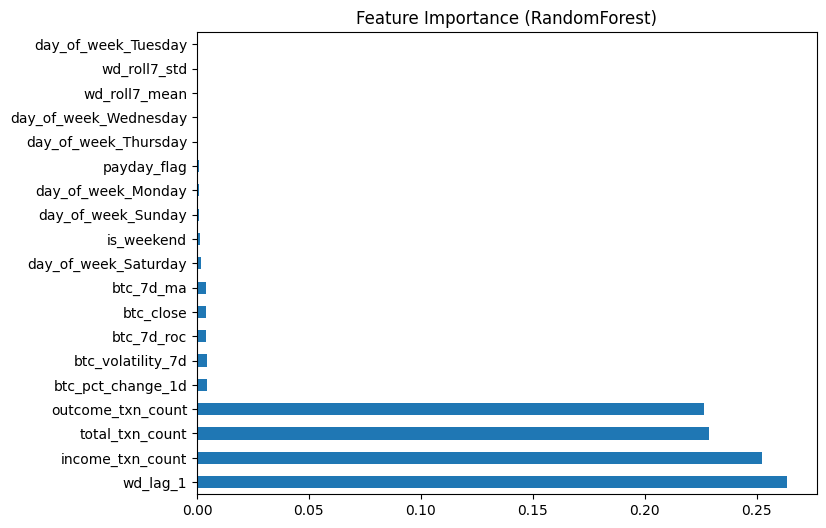

In [20]:
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 10 important features:")
print(imp.head(10))

imp.plot(kind="barh", figsize=(8,6), title="Feature Importance (RandomForest)")


In [21]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

xgb = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist"
)
xgb.fit(X_tr, y_tr)

pred_xgb = xgb.predict(X_va)

rmse_xgb = np.sqrt(mean_squared_error(y_va, pred_xgb))
mape_xgb = mean_absolute_percentage_error(
    y_va.replace(0, np.nan),
    pred_xgb
)
print(f"[XGB] Validation RMSE: {rmse_xgb:,.2f}")
print(f"[XGB] Validation MAPE: {mape_xgb*100:,.2f}%")


[XGB] Validation RMSE: 3,733.07
[XGB] Validation MAPE: 7.01%


In [22]:
# Save the processed data to upload on S3
from pathlib import Path
PROC = Path("../data/data_processed")
PROC.mkdir(parents=True, exist_ok=True)


merged.to_csv(PROC / "atm_crypto_merged_daily.csv", index=False)
print("Wrote:", PROC / "atm_crypto_merged_daily.csv")


PermissionError: [Errno 13] Permission denied: '..\\data\\data_processed\\atm_crypto_merged_daily.csv'

In [ ]:
merged.tail()

,date,atm_id,atm_city,total_balance,income_txn_count,outcome_txn_count,total_income,total_outcome,total_txn_count,withdrawals_usd,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_pct_change_1d,btc_7d_roc,btc_7d_ma,btc_volatility_7d,day_of_week,is_weekend,payday_flag,y_tomorrow
2508,2020-01-03,atm3500099,Izmir,6530,611,683,40725,44715,1294,44715,6956.64,7402.31,6853.53,7339.97,8452.875525,0.055629,0.017669,7231.535714,0.031267,Friday,False,False,37995.0
2509,2020-01-04,atm3500099,Izmir,33495,489,615,33570,37995,1104,37995,7339.97,7396.10,7247.73,7291.27,3605.742694,-0.006635,-0.003473,7227.905714,0.030986,Saturday,True,False,36460.0
2510,2020-01-05,atm3500099,Izmir,37595,632,604,41130,36460,1236,36460,7294.00,7495.00,7269.71,7430.83,2614.947783,0.019141,0.001190,7229.167143,0.031405,Sunday,True,False,39240.0
2511,2020-01-06,atm3500099,Izmir,26705,591,623,38375,39240,1214,39240,7431.63,7614.95,7310.00,7525.46,4138.118201,0.012735,0.041792,7272.294286,0.029144,Monday,False,False,42840.0
2512,2020-01-07,atm3500099,Izmir,19675,547,680,37050,42840,1227,42840,7531.73,8134.95,7516.97,8050.00,13507.546937,0.069702,0.127486,7402.325714,0.036201,Tuesday,False,False,NaN


In [ ]:
# Using last date as 'simulation' date
simulation_date = merged['date'].max()  

daily = merged[merged['date'] == simulation_date].copy()

# Keep a tidy set of columns for the demo load (adjust if you like)
daily_cols = [
    "date","atm_id","atm_city",
    "withdrawals_usd","total_txn_count","income_txn_count","outcome_txn_count",
    "btc_close","btc_pct_change_1d","btc_7d_roc","btc_7d_ma","btc_volatility_7d",
    "is_weekend","payday_flag"
]
daily = daily[[c for c in daily_cols if c in daily.columns]]

# Save into a 'loads/' subfolder locally
LOADS = PROC / "loads"
LOADS.mkdir(parents=True, exist_ok=True)
daily_path = LOADS / f"atm_forecast_{simulation_date}.csv"
daily.to_csv(daily_path, index=False)
print("Wrote daily load file:", daily_path)

Wrote daily load file: ..\data\data_processed\loads\atm_forecast_2020-01-07.csv


In [23]:
preds_path = PROC / "validation_predictions.csv"
try:
    out_pred.to_csv(preds_path, index=False)
    print("Wrote:", preds_path)
except NameError:
    print("Note: 'out_pred' not found. If you want predictions exported, run the training cells first.")


Note: 'out_pred' not found. If you want predictions exported, run the training cells first.


In [25]:
merged.tail()

,date,atm_id,atm_city,total_balance,income_txn_count,outcome_txn_count,total_income,total_outcome,total_txn_count,withdrawals_usd,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_pct_change_1d,btc_7d_roc,btc_7d_ma,btc_volatility_7d,day_of_week,is_weekend,payday_flag,y_tomorrow
2508,2020-01-03,atm3500099,Izmir,6530,611,683,40725,44715,1294,44715,6956.64,7402.31,6853.53,7339.97,8452.875525,0.055629,0.017669,7231.535714,0.031267,Friday,False,False,37995.0
2509,2020-01-04,atm3500099,Izmir,33495,489,615,33570,37995,1104,37995,7339.97,7396.10,7247.73,7291.27,3605.742694,-0.006635,-0.003473,7227.905714,0.030986,Saturday,True,False,36460.0
2510,2020-01-05,atm3500099,Izmir,37595,632,604,41130,36460,1236,36460,7294.00,7495.00,7269.71,7430.83,2614.947783,0.019141,0.001190,7229.167143,0.031405,Sunday,True,False,39240.0
2511,2020-01-06,atm3500099,Izmir,26705,591,623,38375,39240,1214,39240,7431.63,7614.95,7310.00,7525.46,4138.118201,0.012735,0.041792,7272.294286,0.029144,Monday,False,False,42840.0
2512,2020-01-07,atm3500099,Izmir,19675,547,680,37050,42840,1227,42840,7531.73,8134.95,7516.97,8050.00,13507.546937,0.069702,0.127486,7402.325714,0.036201,Tuesday,False,False,NaN


In [24]:
PROC = Path("../data/data_processed")
merged = pd.read_csv(PROC / "atm_crypto_merged_daily.csv")

# Keep ONLY the 14 columns (in the same order as atm.stg_daily)
cols_for_redshift = [
    "date","atm_id","atm_city",
    "withdrawals_usd","total_txn_count","income_txn_count","outcome_txn_count",
    "btc_close","btc_pct_change_1d","btc_7d_roc","btc_7d_ma","btc_volatility_7d",
    "is_weekend","payday_flag"
]

# Subset, coerce types to strings where needed to avoid weird NaNs in CSV
df_out = merged.loc[:, [c for c in cols_for_redshift if c in merged.columns]].copy()

# Ensure booleans are plain true/false strings (not 0/1, not NaN)
for bcol in ["is_weekend","payday_flag"]:
    if bcol in df_out.columns:
        df_out[bcol] = df_out[bcol].astype(str).str.lower()

# Write a clean export for Redshift
out_path = PROC / "atm_crypto_for_redshift.csv"
df_out.to_csv(out_path, index=False)
print("Wrote:", out_path)

Wrote: ..\data\data_processed\atm_crypto_for_redshift.csv


In [26]:
df_out.head()

,date,atm_id,atm_city,withdrawals_usd,total_txn_count,income_txn_count,outcome_txn_count,btc_close,btc_pct_change_1d,btc_7d_roc,btc_7d_ma,btc_volatility_7d,is_weekend,payday_flag
0,2020-01-01,atm350000,Izmir,39650,1118,525,593,7225.58,0.012017,0.008870,7270.584286,0.020342,false,true
1,2020-01-02,atm350000,Izmir,39135,1164,549,615,6953.17,-0.037701,-0.054499,7213.330000,0.021516,false,false
2,2020-01-03,atm350000,Izmir,46075,1162,501,661,7339.97,0.055629,0.017669,7231.535714,0.031267,false,false
3,2020-01-04,atm350000,Izmir,38510,1194,603,591,7291.27,-0.006635,-0.003473,7227.905714,0.030986,true,false
4,2020-01-05,atm350000,Izmir,44990,1189,486,703,7430.83,0.019141,0.001190,7229.167143,0.031405,true,false
